In [16]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.measure import shannon_entropy
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import cv2

# Phân tích

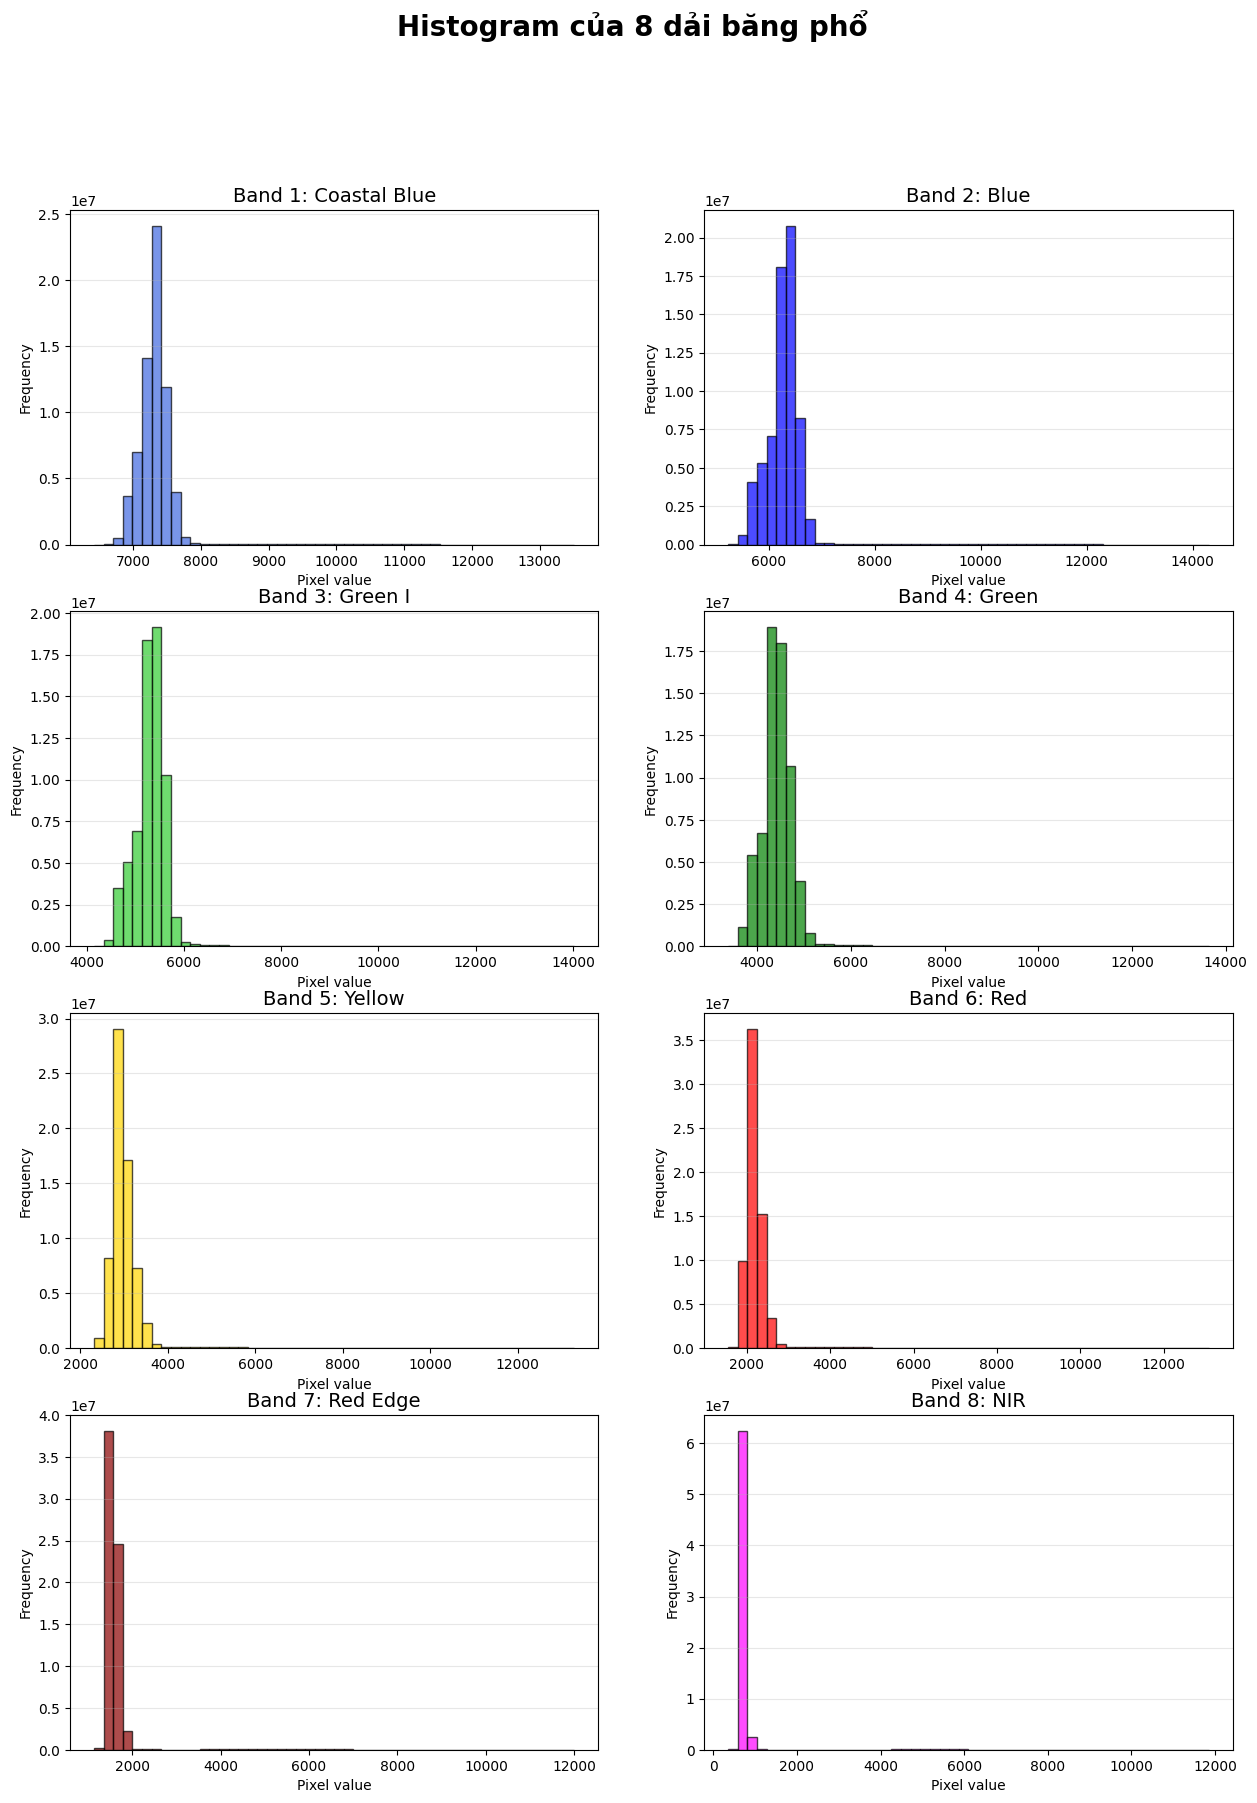

In [2]:
fp = './data_test/task/20260117_034208_52_2511_3B_AnalyticMS_8b.tif'

band_names = [
    'Coastal Blue', 'Blue', 'Green I', 'Green', 
    'Yellow', 'Red', 'Red Edge', 'NIR'
]

colors = [
    'royalblue', 'blue', 'limegreen', 'green', 
    'gold', 'red', 'darkred', 'magenta'
]

with rasterio.open(fp) as src:
    fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    axes = axes.ravel()
    
    fig.suptitle('Histogram của 8 dải băng phổ', fontsize=20, fontweight='bold')

    for i in range(1, 9):
        band_data = src.read(i, masked=True)
        
        data_flatten = band_data.compressed() 
        
        axes[i-1].hist(data_flatten, bins=50, color=colors[i-1], alpha=0.7, edgecolor='black')
        
        axes[i-1].set_title(f'Band {i}: {band_names[i-1]}', fontsize=14)
        axes[i-1].set_xlabel('Pixel value')
        axes[i-1].set_ylabel('Frequency')
        axes[i-1].grid(axis='y', alpha=0.3)
    plt.show();

/tmp/ipykernel_140700/2834605626.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Band Name', y='Pixel Value', data=df_final,


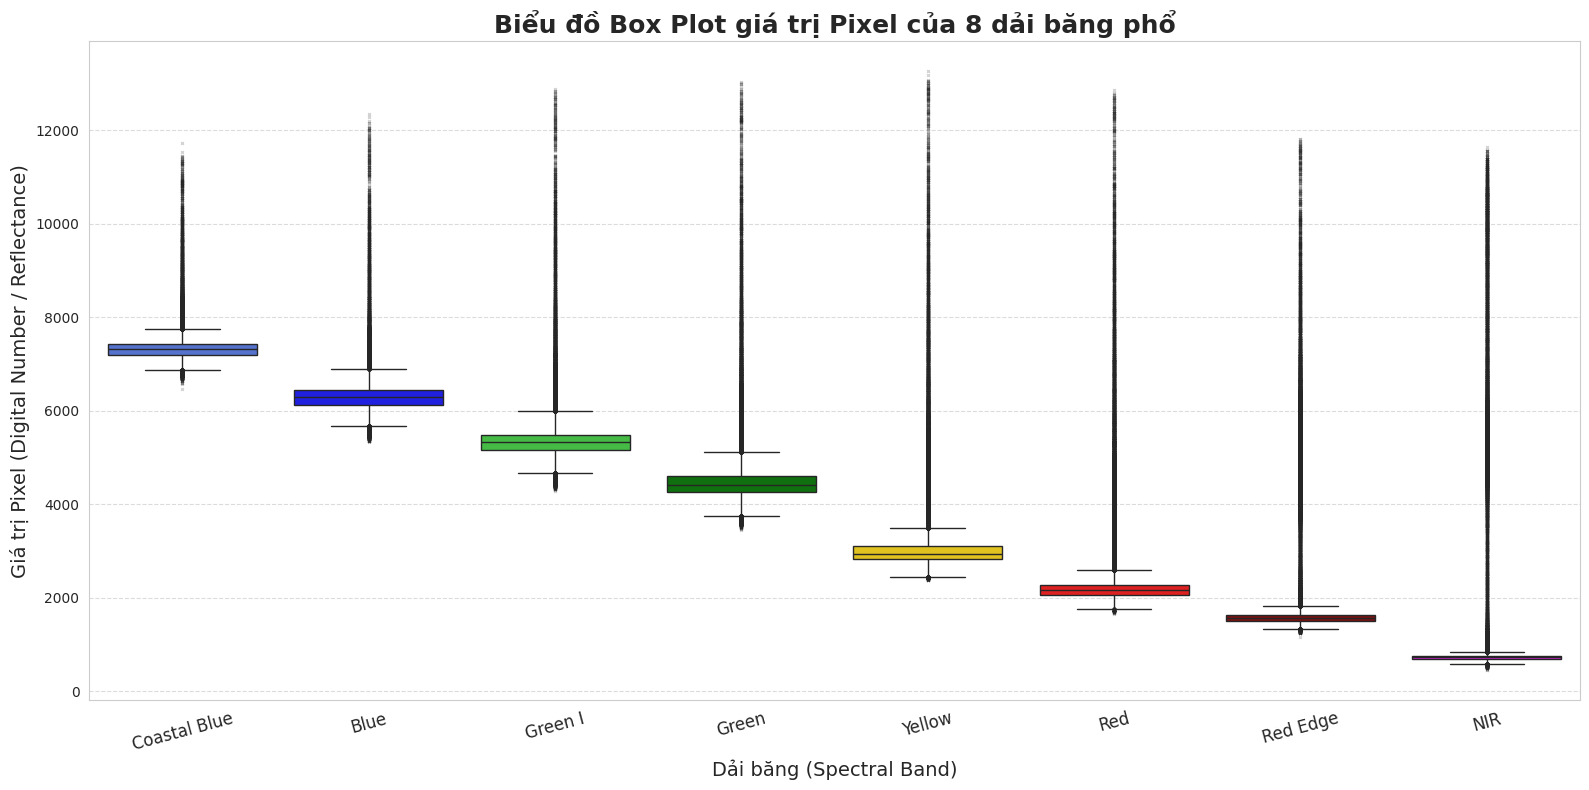

In [3]:
fp_bp = './data_test/task/20260117_034208_52_2511_3B_AnalyticMS_8b.tif'

sampling_rate = 0.01 

all_band_data = []

with rasterio.open(fp_bp) as src:
    total_pixels = src.width * src.height
    num_samples = int(total_pixels * sampling_rate)
    
    indices = np.random.choice(total_pixels, num_samples, replace=False)
    
    rows = indices // src.width
    cols = indices % src.width

    for i in range(1, 9):
        band_data_sampled = src.read(i, masked=True)[rows, cols]
        
        clean_data = band_data_sampled.compressed()
        
        df_band = pd.DataFrame({
            'Pixel Value': clean_data,
            'Band Name': band_names[i-1]
        })
        all_band_data.append(df_band)

df_final = pd.concat(all_band_data, ignore_index=True)

plt.figure(figsize=(16, 8))
sns.set_style("whitegrid") 


ax = sns.boxplot(x='Band Name', y='Pixel Value', data=df_final, 
                 palette=colors, order=band_names, notch=False,
                 flierprops={"marker": "x", "markersize": 2, "alpha": 0.2})

plt.title('Biểu đồ Box Plot giá trị Pixel của 8 dải băng phổ', fontsize=18, fontweight='bold')
plt.xlabel('Dải băng (Spectral Band)', fontsize=14)
plt.ylabel('Giá trị Pixel (Digital Number / Reflectance)', fontsize=14)
plt.xticks(rotation=15, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show();

# Convert ảnh thông qua Python

In [17]:
INPUT_PATH = "./data_test/task/20260117_034208_52_2511_3B_AnalyticMS_8b.tif"
OUTPUT_TIF = "output_8bit_georeferenced_3sample.tif"
OUTPUT_PNG = "output_natural_color_3sample.png"

R_BAND, G_BAND, B_BAND = 6, 4, 2 

GAMMA_VISUAL = 1.8
GAMMA_TIF = 1.0

PERCENTILES = (0.5, 99.5)
STRETCH_METHOD = "percentile"
STD_MULTIPLIER = 3


def get_robust_stats(src):
    stats = {}
    sample_factor = 3
    
    for b in range(1, src.count + 1):
        data = src.read(b, out_shape=(1, src.height // sample_factor, src.width // sample_factor), masked=True)
        valid_data = data.compressed()
        
        if len(valid_data) == 0:
            stats[b] = (0, 1)
            continue
            
        if STRETCH_METHOD == "percentile":
            pmin, pmax = np.percentile(valid_data, PERCENTILES)
        else:
            mean = np.mean(valid_data)
            std = np.std(valid_data)
            pmin = mean - (STD_MULTIPLIER * std)
            pmax = mean + (STD_MULTIPLIER * std)
            
            pmin = max(pmin, np.min(valid_data))
            pmax = min(pmax, np.max(valid_data))
            
        stats[b] = (pmin, pmax)
        print(f"Band {b}: Range [{pmin:.1f} - {pmax:.1f}]")
    return stats


def apply_visual_stretch(data, pmin, pmax, gamma=1.0, nodata=0):
    mask = (data == nodata)
    
    data = np.clip(data, pmin, pmax)
    data = (data - pmin) / (pmax - pmin + 1e-6)
    
    if gamma != 1.0:
        data = np.power(data, 1.0 / gamma)
        
    data_8bit = (data * 255).astype(np.uint8)
    data_8bit[mask] = 0
    return data_8bit


def evaluate_multiband(src, output_path, sample_w):
    results = []

    with rasterio.open(output_path) as dst:
        for b in range(1, src.count + 1):
            orig = src.read(b, window=sample_w).astype(np.float32)
            conv = dst.read(b, window=sample_w).astype(np.float32)

            orig_norm = (orig - orig.min()) / (orig.max() - orig.min() + 1e-6)
            conv_norm = conv / 255.0

            psnr = peak_signal_noise_ratio(orig_norm, conv_norm, data_range=1.0)
            ssim_val = structural_similarity(orig_norm, conv_norm, data_range=1.0)
            entropy = shannon_entropy(conv)

            results.append((psnr, ssim_val, entropy))

            print(f"Band {b}: PSNR={psnr:.2f} dB | SSIM={ssim_val:.4f} | Entropy={entropy:.2f}")

    avg_psnr = np.mean([r[0] for r in results])
    avg_ssim = np.mean([r[1] for r in results])
    avg_entropy = np.mean([r[2] for r in results])

    print("\n===== Tổng kết =====")
    print(f"Avg PSNR   : {avg_psnr:.2f} dB")
    print(f"Avg SSIM   : {avg_ssim:.4f}")
    print(f"Avg Entropy: {avg_entropy:.2f}")


def main():
    with rasterio.open(INPUT_PATH) as src:
        nodata_val = src.nodata if src.nodata is not None else 0
        stats = get_robust_stats(src)
        
        profile = src.profile.copy()
        profile.update(dtype=rasterio.uint8, count=src.count, nodata=0, compress='lzw')
        
        rgb_buffer = np.zeros((src.height, src.width, 3), dtype=np.uint8)

        with rasterio.open(OUTPUT_TIF, 'w', **profile) as dst:
            block_size = 1024

            for y in tqdm(range(0, src.height, block_size), desc="Processing Tiles"):
                for x in range(0, src.width, block_size):
                    window = Window(x, y, min(block_size, src.width - x), min(block_size, src.height - y))
                    
                    chunk = src.read(window=window).astype(np.float32)
                    chunk_8bit = np.zeros_like(chunk, dtype=np.uint8)
                    
                    for i in range(src.count):
                        band_idx = i + 1
                        pmin, pmax = stats[band_idx]

                        chunk_8bit[i] = apply_visual_stretch(
                            chunk[i], pmin, pmax,
                            gamma=GAMMA_TIF,
                            nodata=nodata_val
                        )
                    
                    dst.write(chunk_8bit, window=window)

                    y_end = y + window.height
                    x_end = x + window.width

                    rgb_buffer[y:y_end, x:x_end, 0] = apply_visual_stretch(
                        chunk[R_BAND-1], *stats[R_BAND], gamma=GAMMA_VISUAL
                    )
                    rgb_buffer[y:y_end, x:x_end, 1] = apply_visual_stretch(
                        chunk[G_BAND-1], *stats[G_BAND], gamma=GAMMA_VISUAL
                    )
                    rgb_buffer[y:y_end, x:x_end, 2] = apply_visual_stretch(
                        chunk[B_BAND-1], *stats[B_BAND], gamma=GAMMA_VISUAL
                    )

        cv2.imwrite(OUTPUT_PNG, cv2.cvtColor(rgb_buffer, cv2.COLOR_RGB2BGR))

        print("\nKiểm tra chất lượng ảnh sau biến đổi")

        mid_y, mid_x = src.height // 2, src.width // 2
        sample_w = Window(mid_x, mid_y, min(512, src.width-mid_x), min(512, src.height-mid_y))
        
        evaluate_multiband(src, OUTPUT_TIF, sample_w)


if __name__ == "__main__":
    main()

Band 1: Range [6843.0 - 7975.0]
Band 2: Range [5577.0 - 7195.0]
Band 3: Range [4561.0 - 6793.0]
Band 4: Range [3729.0 - 6383.0]
Band 5: Range [2503.0 - 5897.0]
Band 6: Range [1842.0 - 5447.9]
Band 7: Range [1372.0 - 6053.0]
Band 8: Range [627.0 - 7095.0]


Processing Tiles: 100%|██████████| 8/8 [00:18<00:00,  2.29s/it]



Kiểm tra chất lượng ảnh sau biến đổi
Band 1: PSNR=21.26 dB | SSIM=0.8517 | Entropy=5.88
Band 2: PSNR=24.06 dB | SSIM=0.7655 | Entropy=5.58
Band 3: PSNR=17.70 dB | SSIM=0.6717 | Entropy=5.52
Band 4: PSNR=13.34 dB | SSIM=0.6154 | Entropy=5.56
Band 5: PSNR=9.35 dB | SSIM=0.3458 | Entropy=4.84
Band 6: PSNR=8.80 dB | SSIM=0.1831 | Entropy=4.57
Band 7: PSNR=7.11 dB | SSIM=0.0802 | Entropy=3.70
Band 8: PSNR=6.81 dB | SSIM=0.0212 | Entropy=2.62

===== Tổng kết =====
Avg PSNR   : 13.55 dB
Avg SSIM   : 0.4418
Avg Entropy: 4.78
